# SynAugment: data augmentation

`SynAugment` expands a panel of real series with synthetic look-alikes. For each input series it detects the pattern (seasonality, trend, stationarity), picks a matching generator, fits its parameters, and draws new series that share the original's statistical fingerprint — a cheap way to give a global model more to learn from.

::: {.callout-tip}
## Two augmentation strategies

- **`augment`** (this guide) — fit a generator per series and draw statistically similar copies.
- **[`mixup`](#tsmixup-convex-combinations-of-real-series)** — blend several real series with convex weights (TSMixup), covered at the end.

Fit augmentation on the **training split only** — fitting on validation or test observations leaks information into training.
:::

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from synforecast import SynAugment
from synforecast.generators import RandomWalkGenerator, SeasonalGenerator

## Basic Augmentation

Create a simple random walk series and augment it with 3 synthetic copies.

In [ ]:
n = 100
np.random.seed(42)
df = pl.DataFrame(
    {
        "unique_id": ["series_0"] * n,
        "ds": pl.datetime_range(
            pl.datetime(2020, 1, 1),
            pl.datetime(2020, 1, 1) + pl.duration(hours=n - 1),
            interval="1h",
            eager=True,
        ),
        "y": np.cumsum(np.random.randn(n) * 0.5 + 0.01),
    }
)

print(f"Original dataset: {len(df)} rows, {df['unique_id'].n_unique()} series")

augmenter = SynAugment(seed=42)
augmented_df = augmenter.augment(df, n_augment=3)

print(
    f"Augmented dataset: {len(augmented_df)} rows, {augmented_df['unique_id'].n_unique()} series"
)
print(f"Series IDs: {sorted(augmented_df['unique_id'].unique().to_list())}")

Original dataset: 100 rows, 1 series
Augmented dataset: 400 rows, 4 series
Series IDs: ['series_0', 'series_0_aug_0', 'series_0_aug_1', 'series_0_aug_2']


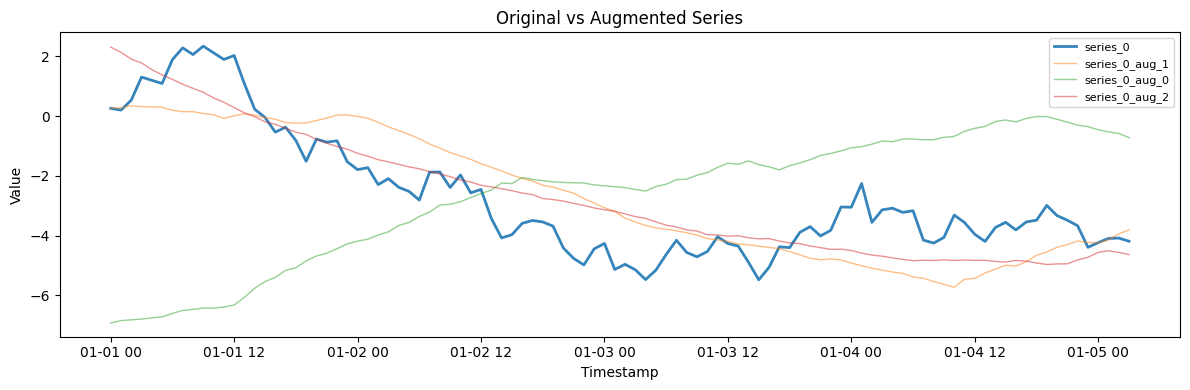

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in augmented_df["unique_id"].unique().to_list():
    series = augmented_df.filter(pl.col("unique_id") == uid)
    is_original = "aug" not in uid
    ax.plot(series["ds"].to_list(), series["y"].to_list(),
            label=uid, alpha=0.9 if is_original else 0.5,
            linewidth=2 if is_original else 1)
ax.set_title("Original vs Augmented Series")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Analyzing Series Before Augmentation

SynAugment analyzes each series to detect its properties and recommend the best generator.

In [ ]:
n = 150
t = np.arange(n)

seasonal_values = 50 + 10 * np.sin(2 * np.pi * t / 24) + np.random.randn(n) * 2
random_walk_values = np.cumsum(np.random.randn(n))
intermittent_values = np.zeros(n)
demand_times = np.random.choice(n, size=30, replace=False)
intermittent_values[demand_times] = np.random.randint(1, 20, 30)

multi_df = pl.DataFrame(
    {
        "unique_id": ["seasonal"] * n + ["random_walk"] * n + ["intermittent"] * n,
        "ds": list(
            pl.datetime_range(
                pl.datetime(2020, 1, 1),
                pl.datetime(2020, 1, 1) + pl.duration(hours=n - 1),
                interval="1h",
                eager=True,
            )
        )
        * 3,
        "y": list(seasonal_values)
        + list(random_walk_values)
        + list(intermittent_values),
    }
)

augmenter = SynAugment(seed=42)
analysis = augmenter.analyze(multi_df)

print("Analysis results for each series:")
for series_id, info in analysis.items():
    print(f"\n  {series_id}:")
    print(f"    Recommended generator: {info['recommended_generator']}")
    props = info["properties"]
    print(f"    Has seasonality: {props['seasonality']['has_seasonality']}")
    print(f"    Has trend: {props['trend']['has_trend']}")
    print(f"    Is stationary: {props['stationarity']['is_stationary']}")
    print(f"    Is intermittent: {props['intermittency']['is_intermittent']}")

Analysis results for each series:

  intermittent:
    Recommended generator: IntermittentDemandGenerator
    Has seasonality: False
    Has trend: False
    Is stationary: True
    Is intermittent: True

  random_walk:
    Recommended generator: RegimeSwitchingGenerator
    Has seasonality: True
    Has trend: True
    Is stationary: False
    Is intermittent: False

  seasonal:
    Recommended generator: RegimeSwitchingGenerator
    Has seasonality: True
    Has trend: False
    Is stationary: True
    Is intermittent: False


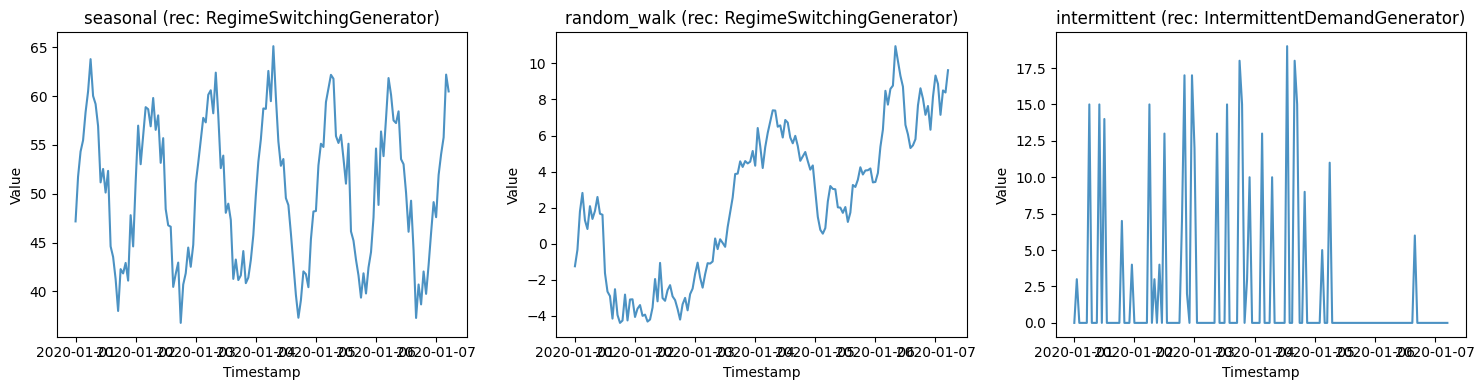

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
series_names = ["seasonal", "random_walk", "intermittent"]
for i, name in enumerate(series_names):
    series = multi_df.filter(pl.col("unique_id") == name)
    axes[i].plot(series["ds"].to_list(), series["y"].to_list(), alpha=0.8)
    axes[i].set_title(f"{name} (rec: {analysis[name]['recommended_generator']})")
    axes[i].set_xlabel("Timestamp")
    axes[i].set_ylabel("Value")
plt.tight_layout()
plt.show()

## Using Generator Overrides

Override the auto-detected generator for specific series when you want to use a particular model.

In [ ]:
augmented_override = augmenter.augment(
    multi_df,
    n_augment=1,
    generator_override={
        "seasonal": "SARIMAGenerator",
        "random_walk": "FractionalBrownianMotionGenerator",
    },
)

print(f"Augmented with overrides: {augmented_override['unique_id'].n_unique()} series")
unique_ids = sorted(augmented_override["unique_id"].unique().to_list())
print(f"Series IDs: {unique_ids}")

Augmented with overrides: 6 series
Series IDs: ['intermittent', 'intermittent_aug_0', 'random_walk', 'random_walk_aug_0', 'seasonal', 'seasonal_aug_0']


## Comparing Original vs Synthetic Statistics

Verify that the augmented series preserve the statistical properties of the original.

In [ ]:
rw_df = df.clone()
augmented = augmenter.augment(rw_df, n_augment=5)

original = augmented.filter(pl.col("unique_id") == "series_0")
print(f"Original series (series_0):")
print(f"  Mean: {original['y'].mean():.4f}")
print(f"  Std:  {original['y'].std():.4f}")
print(f"  Min:  {original['y'].min():.4f}")
print(f"  Max:  {original['y'].max():.4f}")

print(f"\nSynthetic series:")
for i in range(5):
    aug = augmented.filter(pl.col("unique_id") == f"series_0_aug_{i}")
    print(f"  series_0_aug_{i}: mean={aug['y'].mean():.4f}, std={aug['y'].std():.4f}")

Original series (series_0):
  Mean: -2.6976
  Std:  2.0971
  Min:  -5.4833
  Max:  2.3403

Synthetic series:
  series_0_aug_0: mean=-2.6977, std=2.0970
  series_0_aug_1: mean=-2.6973, std=2.0973
  series_0_aug_2: mean=-2.6975, std=2.0970
  series_0_aug_3: mean=-2.6970, std=2.0973
  series_0_aug_4: mean=-2.6976, std=2.0970


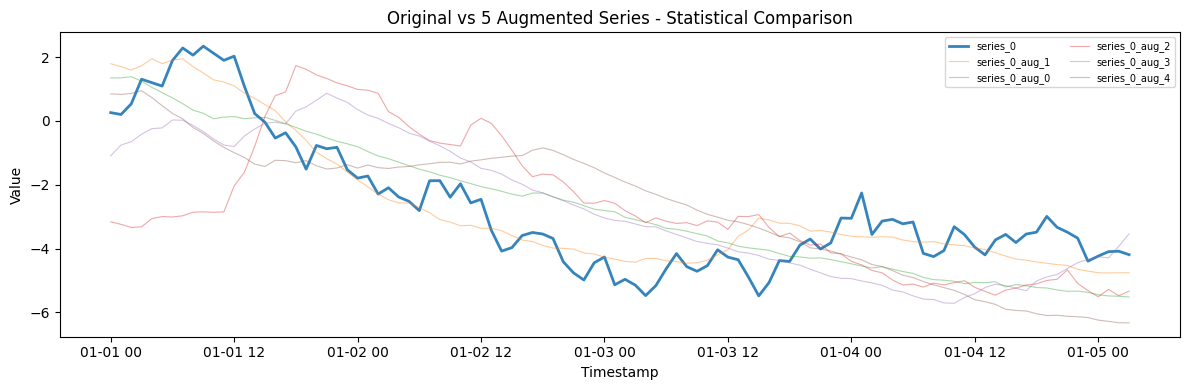

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in augmented["unique_id"].unique().to_list():
    series = augmented.filter(pl.col("unique_id") == uid)
    is_original = "aug" not in uid
    ax.plot(series["ds"].to_list(), series["y"].to_list(),
            label=uid, alpha=0.9 if is_original else 0.4,
            linewidth=2 if is_original else 0.8)
ax.set_title("Original vs 5 Augmented Series - Statistical Comparison")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Augmenting a Generated Dataset

Generate a dataset using SynForecast generators, then augment the combined dataset.

In [ ]:
rw_gen = RandomWalkGenerator(engine="polars", 
    **{
        "min_length": 100,
        "max_length": 100,
        "freq": "h",
        "drift": 0.05,
        "volatility": 1.0,
        "seed": 42,
    }
)

seasonal_gen = SeasonalGenerator(engine="polars", 
    **{
        "min_length": 100,
        "max_length": 100,
        "freq": "h",
        "seasonality_period": 24,
        "seasonality_amplitude": 5.0,
        "trend": 0.01,
        "seed": 43,
    }
)

rw_df = rw_gen.generate(n_series=2)
seasonal_df = seasonal_gen.generate(n_series=2, start_id=2)
combined_df = pl.concat([rw_df, seasonal_df])

print(f"Generated dataset: {combined_df['unique_id'].n_unique()} series")
print(f"Series IDs: {sorted(combined_df['unique_id'].unique().to_list())}")

augmenter = SynAugment(seed=42)
augmented_combined = augmenter.augment(combined_df, n_augment=2)

print(f"\nAfter augmentation: {augmented_combined['unique_id'].n_unique()} series")
print(f"Series IDs: {sorted(augmented_combined['unique_id'].unique().to_list())}")

Generated dataset: 4 series
Series IDs: ['0', '1', '2', '3']

After augmentation: 12 series
Series IDs: ['0', '0_aug_0', '0_aug_1', '1', '1_aug_0', '1_aug_1', '2', '2_aug_0', '2_aug_1', '3', '3_aug_0', '3_aug_1']


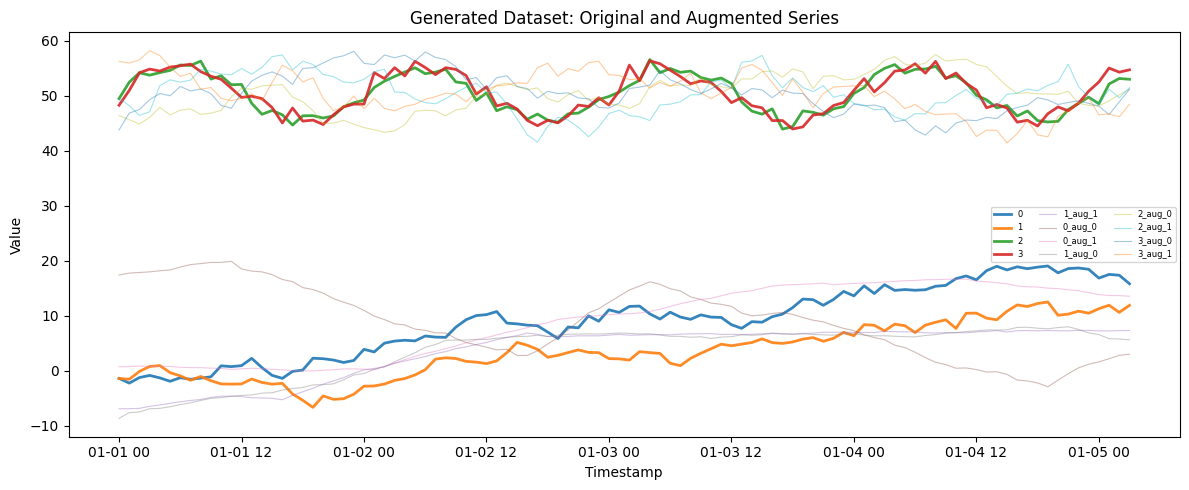

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for uid in augmented_combined["unique_id"].unique().to_list():
    series = augmented_combined.filter(pl.col("unique_id") == uid)
    is_original = "aug" not in uid
    ax.plot(series["ds"].to_list(), series["y"].to_list(),
            label=uid, alpha=0.9 if is_original else 0.4,
            linewidth=2 if is_original else 0.8)
ax.set_title("Generated Dataset: Original and Augmented Series")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend(fontsize=6, ncol=3)
plt.tight_layout()
plt.show()

## TSMixup: convex combinations of real series

`SynAugment.mixup` implements TSMixup, the augmentation used to pretrain the Chronos models (Ansari et al. 2024). Each synthetic series is a convex combination of a random window from `1..max_mix` source series, weighted by a `Dirichlet(alpha)` draw. Unlike `augment`, which fits one generator per series, a mixup series blends the dynamics of several — a cheap way to broaden a small panel without fitting any model.

The blend lives in scaled space: sources are normalized before mixing (`scaling="mean"` divides by the mean absolute value, the Chronos default), so the output shares the scaling rather than any single source's level. Use `scaling="none"` when the series already share a scale.

In [ ]:
mixed = SynAugment(seed=0).mixup(combined_df, n_series=6, max_mix=3, scaling="mean")

mixup_ids = [
    u for u in mixed["unique_id"].unique().to_list() if str(u).startswith("mixup_")
]
print(
    f"{combined_df['unique_id'].n_unique()} source series "
    f"-> {len(mixup_ids)} TSMixup series"
)
mixed.filter(pl.col("unique_id") == mixup_ids[0]).head()

4 source series -> 6 TSMixup series


unique_id,ds,y
cat,datetime[ns],f64
"""mixup_0""",2000-01-01 00:00:00,0.388051
"""mixup_0""",2000-01-01 01:00:00,0.405526
"""mixup_0""",2000-01-01 02:00:00,0.565628
"""mixup_0""",2000-01-01 03:00:00,0.651099
"""mixup_0""",2000-01-01 04:00:00,0.666551


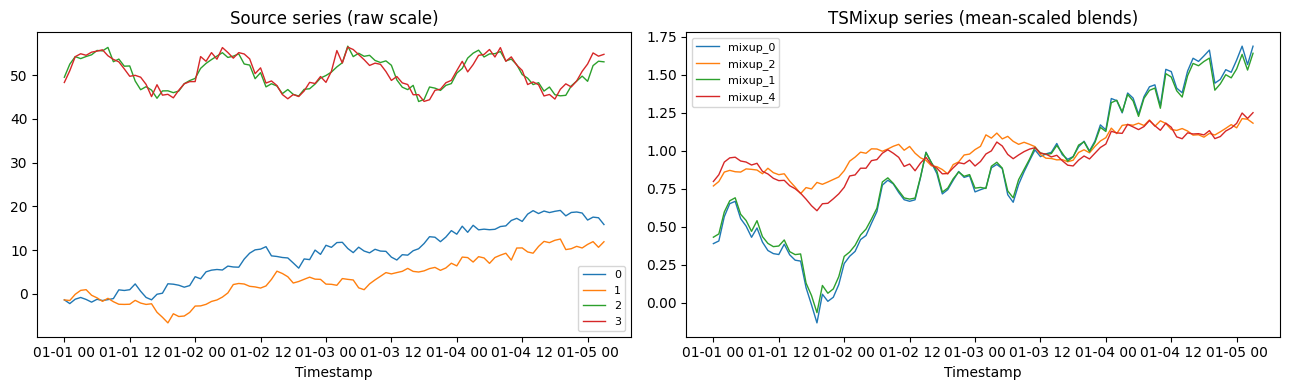

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for uid in combined_df["unique_id"].unique(maintain_order=True).to_list():
    s = combined_df.filter(pl.col("unique_id") == uid)
    axes[0].plot(s["ds"], s["y"], linewidth=1, label=str(uid))
axes[0].set_title("Source series (raw scale)")
axes[0].legend(fontsize=8)
for uid in mixup_ids[:4]:
    s = mixed.filter(pl.col("unique_id") == uid)
    axes[1].plot(s["ds"], s["y"], linewidth=1, label=str(uid))
axes[1].set_title("TSMixup series (mean-scaled blends)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## Low-Level API - augment_single_series

For fine-grained control, use the low-level API to augment individual series directly.

In [ ]:
single_series = df.filter(pl.col("unique_id") == "series_0")
values = single_series["y"].to_numpy()
timestamps = single_series["ds"].to_numpy()

augmenter = SynAugment(seed=42)
augmented_tuples = augmenter.augment_single_series(
    series_id="my_series",
    values=values,
    timestamps=timestamps,
    n_augment=2,
    generator_name=None,
)

print(f"Generated {len(augmented_tuples)} augmented series:")
for aug_id, aug_values, aug_ts in augmented_tuples:
    print(f"  {aug_id}: length={len(aug_values)}, mean={np.mean(aug_values):.4f}")

Generated 2 augmented series:
  my_series_aug_0: length=100, mean=-2.6976
  my_series_aug_1: length=100, mean=-2.6975
